In [ ]:
import os
import path
import random as rn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

In [ ]:
DATASET_PATH = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task")

In [ ]:
for path in DATASET_PATH.iterdir():
    print(path)

/content/drive/MyDrive/brisc2025/segmentation_task/test
/content/drive/MyDrive/brisc2025/segmentation_task/train


In [ ]:
files = list(DATASET_PATH.rglob("*"))

In [ ]:
for file in files[:50]:
    print(file)

/content/drive/MyDrive/brisc2025/segmentation_task/test
/content/drive/MyDrive/brisc2025/segmentation_task/train
/content/drive/MyDrive/brisc2025/segmentation_task/test/images
/content/drive/MyDrive/brisc2025/segmentation_task/test/masks
/content/drive/MyDrive/brisc2025/segmentation_task/train/images
/content/drive/MyDrive/brisc2025/segmentation_task/train/masks
/content/drive/MyDrive/brisc2025/segmentation_task/test/images/brisc2025_test_00891_pi_co_t1.jpg
/content/drive/MyDrive/brisc2025/segmentation_task/test/images/brisc2025_test_00952_pi_sa_t1.jpg
/content/drive/MyDrive/brisc2025/segmentation_task/test/images/brisc2025_test_00492_me_sa_t1.jpg
/content/drive/MyDrive/brisc2025/segmentation_task/test/images/brisc2025_test_00828_pi_co_t1.jpg
/content/drive/MyDrive/brisc2025/segmentation_task/test/images/brisc2025_test_00504_me_sa_t1.jpg
/content/drive/MyDrive/brisc2025/segmentation_task/test/images/brisc2025_test_00726_pi_ax_t1.jpg
/content/drive/MyDrive/brisc2025/segmentation_task/te

In [ ]:
print(f"total files: {len(files)}")

total files: 9592


In [ ]:
extensions = Counter(
    file.suffix.lower()
    for file in files
    if file.is_file()
)

print(extensions)

Counter({'.jpg': 4793, '.png': 4793})


In [ ]:
print(f"total jpg format images: {extensions['.jpg']}\ntotal png format images: {extensions['.png']}")

total jpg format images: 4793
total png format images: 4793


In [ ]:
test_images_path = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images/")

In [ ]:
train_images_path = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/images")

In [ ]:
test_images_paths = list(test_images_path.glob("*"))

In [ ]:
train_images_paths = list(train_images_path.glob("*"))

In [ ]:
def validate_images(image_paths):
    valid_images = []
    corrupted_images = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                img.verify()

            valid_images.append(path)

        except Exception as e:
            corrupted_images.append((path, str(e)))

    return valid_images, corrupted_images

In [ ]:
train_valid, train_corrupted = validate_images(train_images_paths)
test_valid, test_corrupted = validate_images(test_images_paths)

In [ ]:
print("Train")
print("Valid    :", len(train_valid))
print("Corrupted:", len(train_corrupted))

print("\nTest")
print("Valid    :", len(test_valid))
print("Corrupted:", len(test_corrupted))

Train
Valid    : 3933
Corrupted: 0

Test
Valid    : 860
Corrupted: 0


In [ ]:
for path, error in train_corrupted:
    print(path)
    print(error)

In [ ]:
test_mask_path = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/masks")

In [ ]:
test_mask_paths = list(test_mask_path.glob("*"))

In [ ]:
def show_images(images_path, masks_path, n=16, save_path="sample_segmentation.png", save=False):
    image_paths = [
        p for p in images_path.iterdir()
        if p.is_file() and p.suffix.lower() == ".jpg"
    ]
    selected_images = rn.sample(
        image_paths,
        min(n, len(image_paths))
    )
    fig, axes = plt.subplots(
        nrows=len(selected_images),
        ncols=3,
        figsize=(12, 5 * len(selected_images)),
        dpi=120
    )
    if len(selected_images) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, image_path in enumerate(selected_images):
        mask_path = masks_path / f"{image_path.stem}.png"
        if not mask_path.exists():
            print(f"Mask not found: {image_path.name}")
            continue

        img_pil = Image.open(image_path)
        mask_pil = Image.open(mask_path)

        img_size, img_mode = img_pil.size, img_pil.mode
        mask_size, mask_mode = mask_pil.size, mask_pil.mode
        print(
            f"[{image_path.stem}] "
            f"Image -> size: {img_size}, mode: {img_mode} | "
            f"Mask -> size: {mask_size}, mode: {mask_mode}"
        )

        image = np.array(img_pil.convert("L"))
        mask = np.array(mask_pil.convert("L"))

        mask_binary = mask > 127
        overlay = np.stack([image] * 3, axis=-1)
        overlay[mask_binary] = [255, 0, 0]

        axes[i, 0].imshow(image, cmap="gray")
        axes[i, 0].set_title(f"MRI\n{img_size} | {img_mode}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"Mask\n{mask_size} | {mask_mode}", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay", fontsize=9)
        axes[i, 2].axis("off")

    plt.tight_layout()
    if save:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )
        print(f"Saved to: {save_path}")
    plt.show()

[brisc2025_test_00398_me_co_t1] Image -> size: (374, 370), mode: RGB | Mask -> size: (374, 370), mode: L
[brisc2025_test_00843_pi_co_t1] Image -> size: (512, 512), mode: L | Mask -> size: (512, 512), mode: L
[brisc2025_test_00980_pi_sa_t1] Image -> size: (512, 512), mode: L | Mask -> size: (512, 512), mode: L
[brisc2025_test_00505_me_sa_t1] Image -> size: (512, 512), mode: L | Mask -> size: (512, 512), mode: L
[brisc2025_test_00076_gl_ax_t1] Image -> size: (512, 512), mode: L | Mask -> size: (512, 512), mode: L
[brisc2025_test_00722_pi_ax_t1] Image -> size: (512, 512), mode: RGB | Mask -> size: (512, 512), mode: L
[brisc2025_test_00550_me_sa_t1] Image -> size: (512, 512), mode: L | Mask -> size: (512, 512), mode: L
[brisc2025_test_00251_gl_sa_t1] Image -> size: (512, 512), mode: L | Mask -> size: (512, 512), mode: L


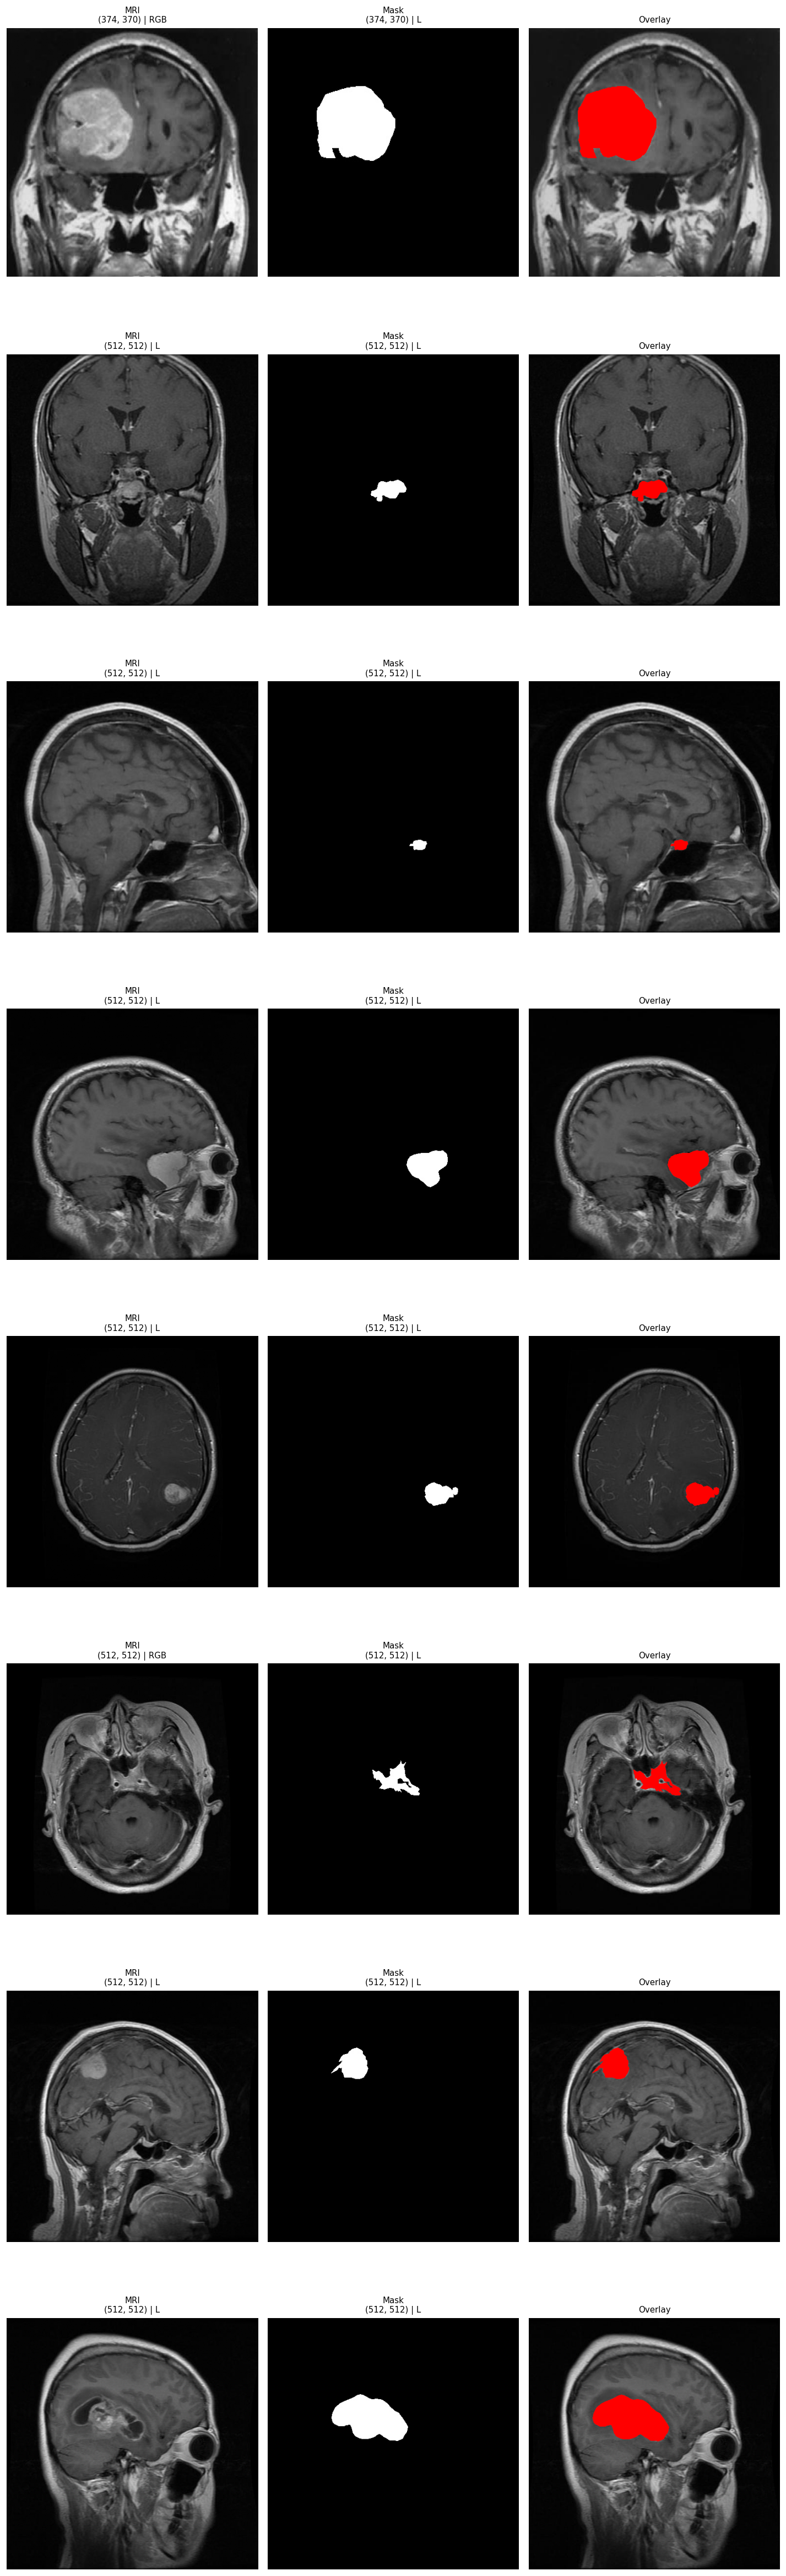

In [ ]:
show_images(
    images_path=test_images_path,
    masks_path=test_mask_path,
    save=False,
    n=8
)

During the validation process, a number of image-mask pairs were randomly selected from the BRISC2025 dataset to check their dimensions and image modes.

The results showed that the spatial dimensions are not consistent across different samples. For example, some samples have dimensions of 512 × 512, while another randomly selected sample has dimensions of 540 × 568.

However, for the randomly inspected samples, the dimensions of each image were consistent with the dimensions of its corresponding segmentation mask. This means that although different samples may have different resolutions, the image-mask pairs are correctly aligned in terms of their spatial dimensions.

Another issue was observed in the image modes. Some MRI images were stored as grayscale (L), while others were stored as RGB (RGB). In contrast, the corresponding segmentation masks were stored as grayscale (L).

For example:

brisc2025_test_00196_gl_sa_t1 → Image: 512 × 512, L | Mask: 512 × 512, L

brisc2025_test_00395_me_co_t1 → Image: 540 × 568, RGB | Mask: 540 × 568, L

brisc2025_test_00077_gl_ax_t1 → Image: 512 × 512, L | Mask: 512 × 512, L

brisc2025_test_00340_me_ax_t1 → Image: 512 × 512, RGB | Mask: 512 × 512, L

Since these samples were selected randomly, these results should be considered representative examples rather than a complete description of every image in the dataset.

Therefore, before training the segmentation model, the complete dataset should be validated and standardized. In particular, all input images should be converted to a consistent channel format, and images and masks should be resized to a common spatial resolution. For masks, nearest-neighbor interpolation should be used to preserve the original segmentation labels.

Overall, the random inspection indicates two important preprocessing considerations: different samples may have different spatial dimensions, and image channel formats are not completely consistent. A complete preprocessing pipeline is therefore required before model training.

In [ ]:
def full_audit(images_path, masks_path):
    size_counter = Counter()
    mode_counter = Counter()
    small_outliers = []
    mismatch = []

    for image_path in Path(images_path).iterdir():
        if not (image_path.is_file() and image_path.suffix.lower() == ".jpg"):
            continue
        mask_path = Path(masks_path) / f"{image_path.stem}.png"
        if not mask_path.exists():
            continue

        img = Image.open(image_path)
        mask = Image.open(mask_path)

        size_counter[img.size] += 1
        mode_counter[img.mode] += 1

        if img.size != mask.size:
            mismatch.append(image_path.stem)

        if img.size[0] < 400 or img.size[1] < 400:
            small_outliers.append((image_path.stem, img.size))

    print("=== Size distribution ===")
    for size, count in size_counter.most_common():
        print(f"{size}: {count}")

    print("\n=== Mode distribution ===")
    for mode, count in mode_counter.most_common():
        print(f"{mode}: {count}")

    print(f"\n=== Image/Mask size mismatches: {len(mismatch)} ===")
    for m in mismatch[:10]:
        print(m)

    print(f"\n=== Small outliers (<400px): {len(small_outliers)} ===")
    for name, size in small_outliers[:10]:
        print(name, size)

    return size_counter, mode_counter, mismatch, small_outliers

In [ ]:
full_audit(
    images_path=test_images_path,
    masks_path=test_mask_path
)

=== Size distribution ===
(512, 512): 738
(225, 225): 7
(256, 256): 5
(442, 442): 4
(554, 554): 3
(210, 240): 3
(201, 251): 3
(455, 500): 2
(200, 223): 2
(228, 221): 2
(212, 237): 2
(341, 395): 2
(239, 248): 1
(645, 439): 1
(214, 235): 1
(313, 393): 1
(221, 228): 1
(232, 261): 1
(630, 423): 1
(416, 395): 1
(300, 258): 1
(352, 322): 1
(591, 650): 1
(534, 674): 1
(209, 241): 1
(315, 315): 1
(215, 234): 1
(369, 395): 1
(214, 216): 1
(278, 306): 1
(367, 395): 1
(480, 480): 1
(306, 306): 1
(540, 568): 1
(217, 232): 1
(224, 216): 1
(200, 252): 1
(722, 690): 1
(291, 340): 1
(318, 354): 1
(206, 245): 1
(300, 345): 1
(200, 235): 1
(472, 546): 1
(440, 278): 1
(351, 398): 1
(491, 624): 1
(341, 377): 1
(213, 237): 1
(369, 398): 1
(530, 526): 1
(305, 337): 1
(239, 224): 1
(273, 326): 1
(314, 358): 1
(374, 370): 1
(208, 243): 1
(212, 238): 1
(528, 581): 1
(290, 339): 1
(216, 216): 1
(304, 410): 1
(312, 401): 1
(262, 308): 1
(201, 207): 1
(206, 249): 1
(252, 303): 1
(213, 236): 1
(286, 356): 1
(205, 

(Counter({(512, 512): 738,
          (239, 248): 1,
          (442, 442): 4,
          (645, 439): 1,
          (214, 235): 1,
          (313, 393): 1,
          (455, 500): 2,
          (221, 228): 1,
          (232, 261): 1,
          (256, 256): 5,
          (630, 423): 1,
          (416, 395): 1,
          (300, 258): 1,
          (352, 322): 1,
          (591, 650): 1,
          (534, 674): 1,
          (200, 223): 2,
          (209, 241): 1,
          (554, 554): 3,
          (315, 315): 1,
          (228, 221): 2,
          (215, 234): 1,
          (369, 395): 1,
          (214, 216): 1,
          (278, 306): 1,
          (367, 395): 1,
          (480, 480): 1,
          (225, 225): 7,
          (306, 306): 1,
          (212, 237): 2,
          (540, 568): 1,
          (217, 232): 1,
          (224, 216): 1,
          (200, 252): 1,
          (722, 690): 1,
          (210, 240): 3,
          (291, 340): 1,
          (318, 354): 1,
          (206, 245): 1,
          (300, 345): 1

## 1. Image Size Distribution

The analysis shows significant variation in image dimensions across the dataset.

The most common resolution is **512 × 512**, with **738 images**.

However, many other resolutions are also present, including `225 × 225`, `256 × 256`, `442 × 442`, `540 × 568`, `1149 × 1019`, `722 × 690`, and several other non-square resolutions.

In total, **99 images were identified as small outliers with dimensions below 400 pixels** in at least one dimension. A large portion of these images have considerably smaller resolutions, such as `200 × 252`, `214 × 235`, `225 × 225`, and `256 × 256`.

This indicates that the dataset does **not have a consistent spatial resolution** and that preprocessing is required before using the data for deep learning.

## 2. Image Mode Distribution

The image mode analysis also revealed inconsistency in the number of image channels:

- **Grayscale (L): 582 images**
- **RGB: 278 images**

Therefore, approximately two-thirds of the images are grayscale, while the remaining images are stored as RGB.

Since MRI images are fundamentally single-channel medical images, converting all input images to a consistent grayscale format can simplify the preprocessing pipeline and ensure that the model receives inputs with the same number of channels.

## 3. Image-Mask Consistency

An important positive result is that:

**Image/Mask size mismatches: 0**

This means that all inspected image-mask pairs have matching spatial dimensions. Therefore, there is no evidence of misalignment between an image and its corresponding segmentation mask based on the size validation.

However, the dimensions are inconsistent **between different samples**. For example, one image-mask pair may be `512 × 512`, while another may be `540 × 568` or `225 × 225`.

## 4. Small Image Outliers

A total of **99 images were detected as small outliers (<400 px)**.

Examples include:

- `brisc2025_test_00295_me_ax_t1` → `200 × 252`
- `brisc2025_test_00316_me_ax_t1` → `214 × 235`
- `brisc2025_test_00278_me_ax_t1` → `312 × 401`
- `brisc2025_test_00397_me_co_t1` → `306 × 306`
- `brisc2025_test_00493_me_sa_t1` → `226 × 214`
- `brisc2025_test_00289_me_ax_t1` → `341 × 372`

These samples should not necessarily be considered corrupted. They may represent images that were originally stored or exported at different resolutions. However, they require attention during preprocessing because neural networks generally require inputs with a consistent spatial size.

## 5. Conclusion

The validation results reveal three main characteristics of the BRISC2025 test dataset:

1. **Image resolutions are highly inconsistent**, although `512 × 512` is by far the dominant resolution.
2. **Image modes are inconsistent**, with both grayscale and RGB images present.
3. **No image-mask size mismatch was detected**, meaning that the corresponding segmentation masks maintain the same spatial dimensions as their images.

Therefore, before training the segmentation model, a standardized preprocessing pipeline should be applied. The recommended approach is to convert all MRI images to a consistent grayscale format and resize all image-mask pairs to a fixed resolution such as **256 × 256 or 512 × 512**.

For segmentation masks, **nearest-neighbor interpolation must be used during resizing** to preserve the original class labels and prevent the creation of invalid intermediate pixel values.

Overall, the dataset appears to have **consistent image-mask pairing but inconsistent image representation and resolution**, making preprocessing an essential step before model training.

# Now for the train folder

In [ ]:
train_mask_paths = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/masks")

In [ ]:
full_audit(images_path=train_images_path, masks_path=train_mask_paths)

=== Size distribution ===
(512, 512): 3766
(256, 256): 25
(225, 225): 8
(442, 442): 4
(455, 500): 3
(474, 474): 2
(200, 223): 2
(554, 554): 2
(201, 251): 2
(213, 237): 2
(212, 237): 2
(341, 395): 2
(485, 510): 2
(685, 681): 1
(202, 202): 1
(900, 741): 1
(502, 502): 1
(940, 900): 1
(224, 219): 1
(402, 396): 1
(217, 232): 1
(238, 212): 1
(212, 238): 1
(226, 212): 1
(215, 234): 1
(239, 224): 1
(530, 526): 1
(314, 358): 1
(491, 624): 1
(254, 325): 1
(329, 314): 1
(313, 393): 1
(323, 342): 1
(343, 367): 1
(298, 354): 1
(201, 207): 1
(400, 400): 1
(470, 432): 1
(360, 378): 1
(1365, 1365): 1
(201, 210): 1
(1280, 1280): 1
(721, 903): 1
(272, 331): 1
(290, 342): 1
(205, 251): 1
(497, 320): 1
(300, 412): 1
(273, 326): 1
(374, 456): 1
(528, 581): 1
(411, 396): 1
(341, 372): 1
(645, 439): 1
(591, 650): 1
(250, 270): 1
(224, 216): 1
(204, 249): 1
(306, 306): 1
(229, 223): 1
(315, 315): 1
(262, 308): 1
(295, 394): 1
(315, 341): 1
(214, 216): 1
(209, 225): 1
(503, 369): 1
(214, 235): 1
(825, 993): 1


(Counter({(512, 512): 3766,
          (685, 681): 1,
          (256, 256): 25,
          (474, 474): 2,
          (202, 202): 1,
          (442, 442): 4,
          (900, 741): 1,
          (502, 502): 1,
          (940, 900): 1,
          (224, 219): 1,
          (402, 396): 1,
          (217, 232): 1,
          (238, 212): 1,
          (212, 238): 1,
          (226, 212): 1,
          (215, 234): 1,
          (239, 224): 1,
          (200, 223): 2,
          (530, 526): 1,
          (314, 358): 1,
          (491, 624): 1,
          (254, 325): 1,
          (329, 314): 1,
          (313, 393): 1,
          (225, 225): 8,
          (323, 342): 1,
          (554, 554): 2,
          (343, 367): 1,
          (298, 354): 1,
          (201, 207): 1,
          (400, 400): 1,
          (470, 432): 1,
          (360, 378): 1,
          (1365, 1365): 1,
          (201, 210): 1,
          (1280, 1280): 1,
          (721, 903): 1,
          (272, 331): 1,
          (290, 342): 1,
          (205, 2


## 1. Dataset Audit

A full audit was run across the entire training split (3,943 image/mask pairs).

**Size distribution**
- `512×512`: 3,766 images (~95.5%)
- Remaining ~4.5% (177 images) span irregular sizes, from very small (`180×218`, `200×223`) up to very large (`1365×1365`, `1275×1427`).

**Mode distribution**
- `L` (grayscale): 2,284 images
- `RGB`: 1,649 images

**Image/Mask size mismatch:** 0 — every mask matches its corresponding image's size; the inconsistency is only across samples, not within pairs.

**Small outliers (<400px):** 129 images (~3.3% of the split)

## 2. Key Finding: Outliers Are Class-Correlated, Not Random

Filename inspection of the 129 outliers shows two dominant groups:

- **`me_*` (meningioma)** — the majority of outliers, at highly irregular sizes (e.g. `212×238`, `374×456`, `503×369`), consistent with the earlier test-split finding.
- **`pi_co` / `pi_sa` (pituitary, coronal/sagittal)** — a consistent secondary group, almost all sitting exactly at `256×256` (e.g. `brisc2025_train_04469_pi_co_t1`, `brisc2025_train_04697_pi_sa_t1`).

This confirms the pattern is **systematic and class/orientation-linked**, not random corruption:
- Meningioma samples come from a source with inconsistent, non-standard resolutions.
- Pituitary coronal/sagittal samples come from a source fixed at `256×256`, distinct from the axial `512×512` standard.
- Glioma and pituitary-axial samples remain consistently `512×512`.

**Implication:** these are two separate systematic export batches, not noise. Discarding them would disproportionately remove meningioma and pituitary (coronal/sagittal) samples, harming class and view-orientation balance.

**Decision:** resize/pad all samples to a common target size rather than drop any — outliers are valid data, not corrupted data.

## 3. Preprocessing Decisions

**Target size — 512×512**
Matches the dominant resolution (~95.5% of the split), is a power of 2 (compatible with standard U-Net downsampling depths), and preserves boundary detail relevant to tumor segmentation.

**Resize strategy**
- Image: bilinear interpolation
- Mask: nearest-neighbor interpolation (mandatory — bilinear/bicubic would corrupt discrete class labels at boundaries)

**Mode normalization**
All images converted to grayscale (`L`) regardless of source mode (`L` or `RGB`), ensuring uniform single-channel tensors for batching.

**Aspect ratio consideration**
Given the two identified subgroups — meningioma (irregular aspect ratios) and pituitary coronal/sagittal (uniform `256×256`) — a pad-or-crop-based resize (e.g. MONAI's `ResizeWithPadOrCrop`) is preferable to direct resize, to avoid distorting anatomy in the meningioma subset while cleanly upscaling the pituitary subset.

Design notes:
- Augmentation (flip, ±15° rotation) applied only to the training split; validation/test remain deterministic.
- Mask tensors kept as `long` dtype (raw class indices) for CrossEntropyLoss/Dice Loss compatibility.
- Image tensors normalized with mean=0.5, std=0.5.


In [ ]:
mask = Image.open("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/masks/brisc2025_test_00001_gl_ax_t1.png")

In [ ]:
np.unique(mask)

array([  0,   1,   2,   3,   4,   5,   7, 248, 249, 250, 251, 252, 253,
       254, 255], dtype=uint8)

In [ ]:
all_values = Counter()
for mask_path in train_mask_paths.glob("*.png"):
    m = np.array(Image.open(mask_path).convert("L"))
    all_values.update(np.unique(m).tolist())

print(sorted(all_values.keys()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255]


In [ ]:
def show_images_with_histogram(images_path, n=8, figsize_per_row=(20, 5)):
    image_paths = [
        p for p in images_path.iterdir()
        if p.is_file() and p.suffix.lower() == ".jpg"
    ]
    selected = rn.sample(image_paths, min(n, len(image_paths)))

    fig, axes = plt.subplots(
        nrows=len(selected), ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * len(selected)),
        dpi=120
    )
    if len(selected) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, image_path in enumerate(selected):
        image = np.array(Image.open(image_path).convert("L"))

        axes[i, 0].imshow(image, cmap="gray")
        axes[i, 0].set_title(f"MRI: {image_path.stem}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].hist(image.ravel(), bins=256, range=(0, 255), color="steelblue")
        axes[i, 1].set_title("Pixel Intensity Histogram", fontsize=9)
        axes[i, 1].set_xlabel("Pixel value")
        axes[i, 1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

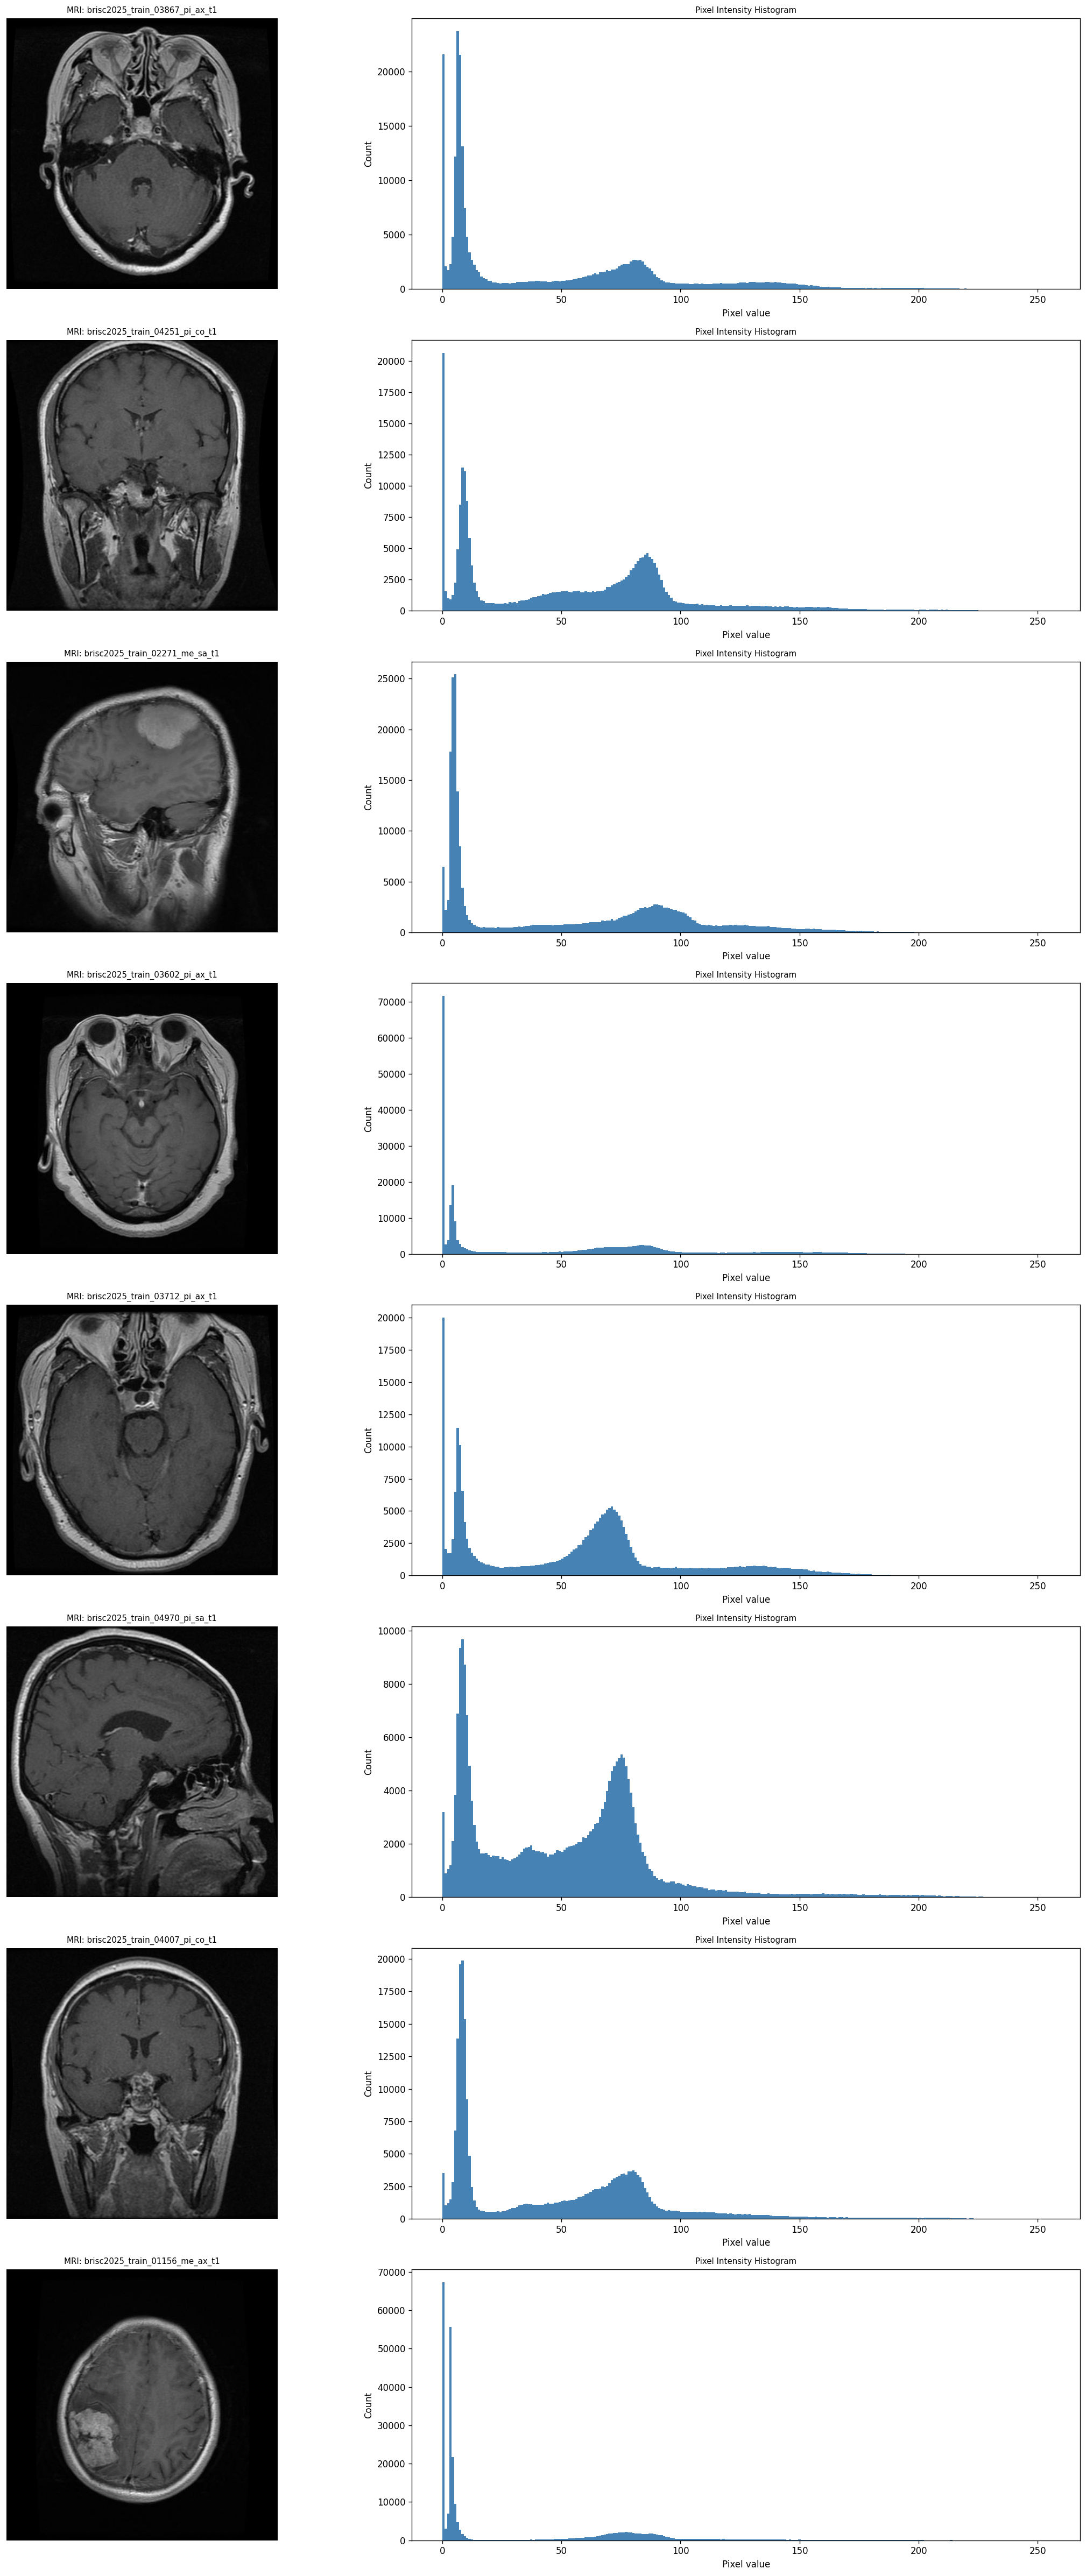

In [ ]:
show_images_with_histogram(
    images_path=train_images_path
)

In [ ]:
def show_masks_with_histogram(masks_path, n=8, figsize_per_row=(20, 5)):
    mask_paths = [
        p for p in masks_path.iterdir()
        if p.is_file() and p.suffix.lower() == ".png"
    ]
    selected = rn.sample(mask_paths, min(n, len(mask_paths)))

    fig, axes = plt.subplots(
        nrows=len(selected), ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * len(selected)),
        dpi=120
    )
    if len(selected) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, mask_path in enumerate(selected):
        mask = np.array(Image.open(mask_path).convert("L"))

        axes[i, 0].imshow(mask, cmap="gray")
        axes[i, 0].set_title(f"Mask: {mask_path.stem}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].hist(mask.ravel(), bins=256, range=(0, 255), color="firebrick")
        axes[i, 1].set_title("Mask Value Histogram", fontsize=9)
        axes[i, 1].set_xlabel("Pixel value")
        axes[i, 1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

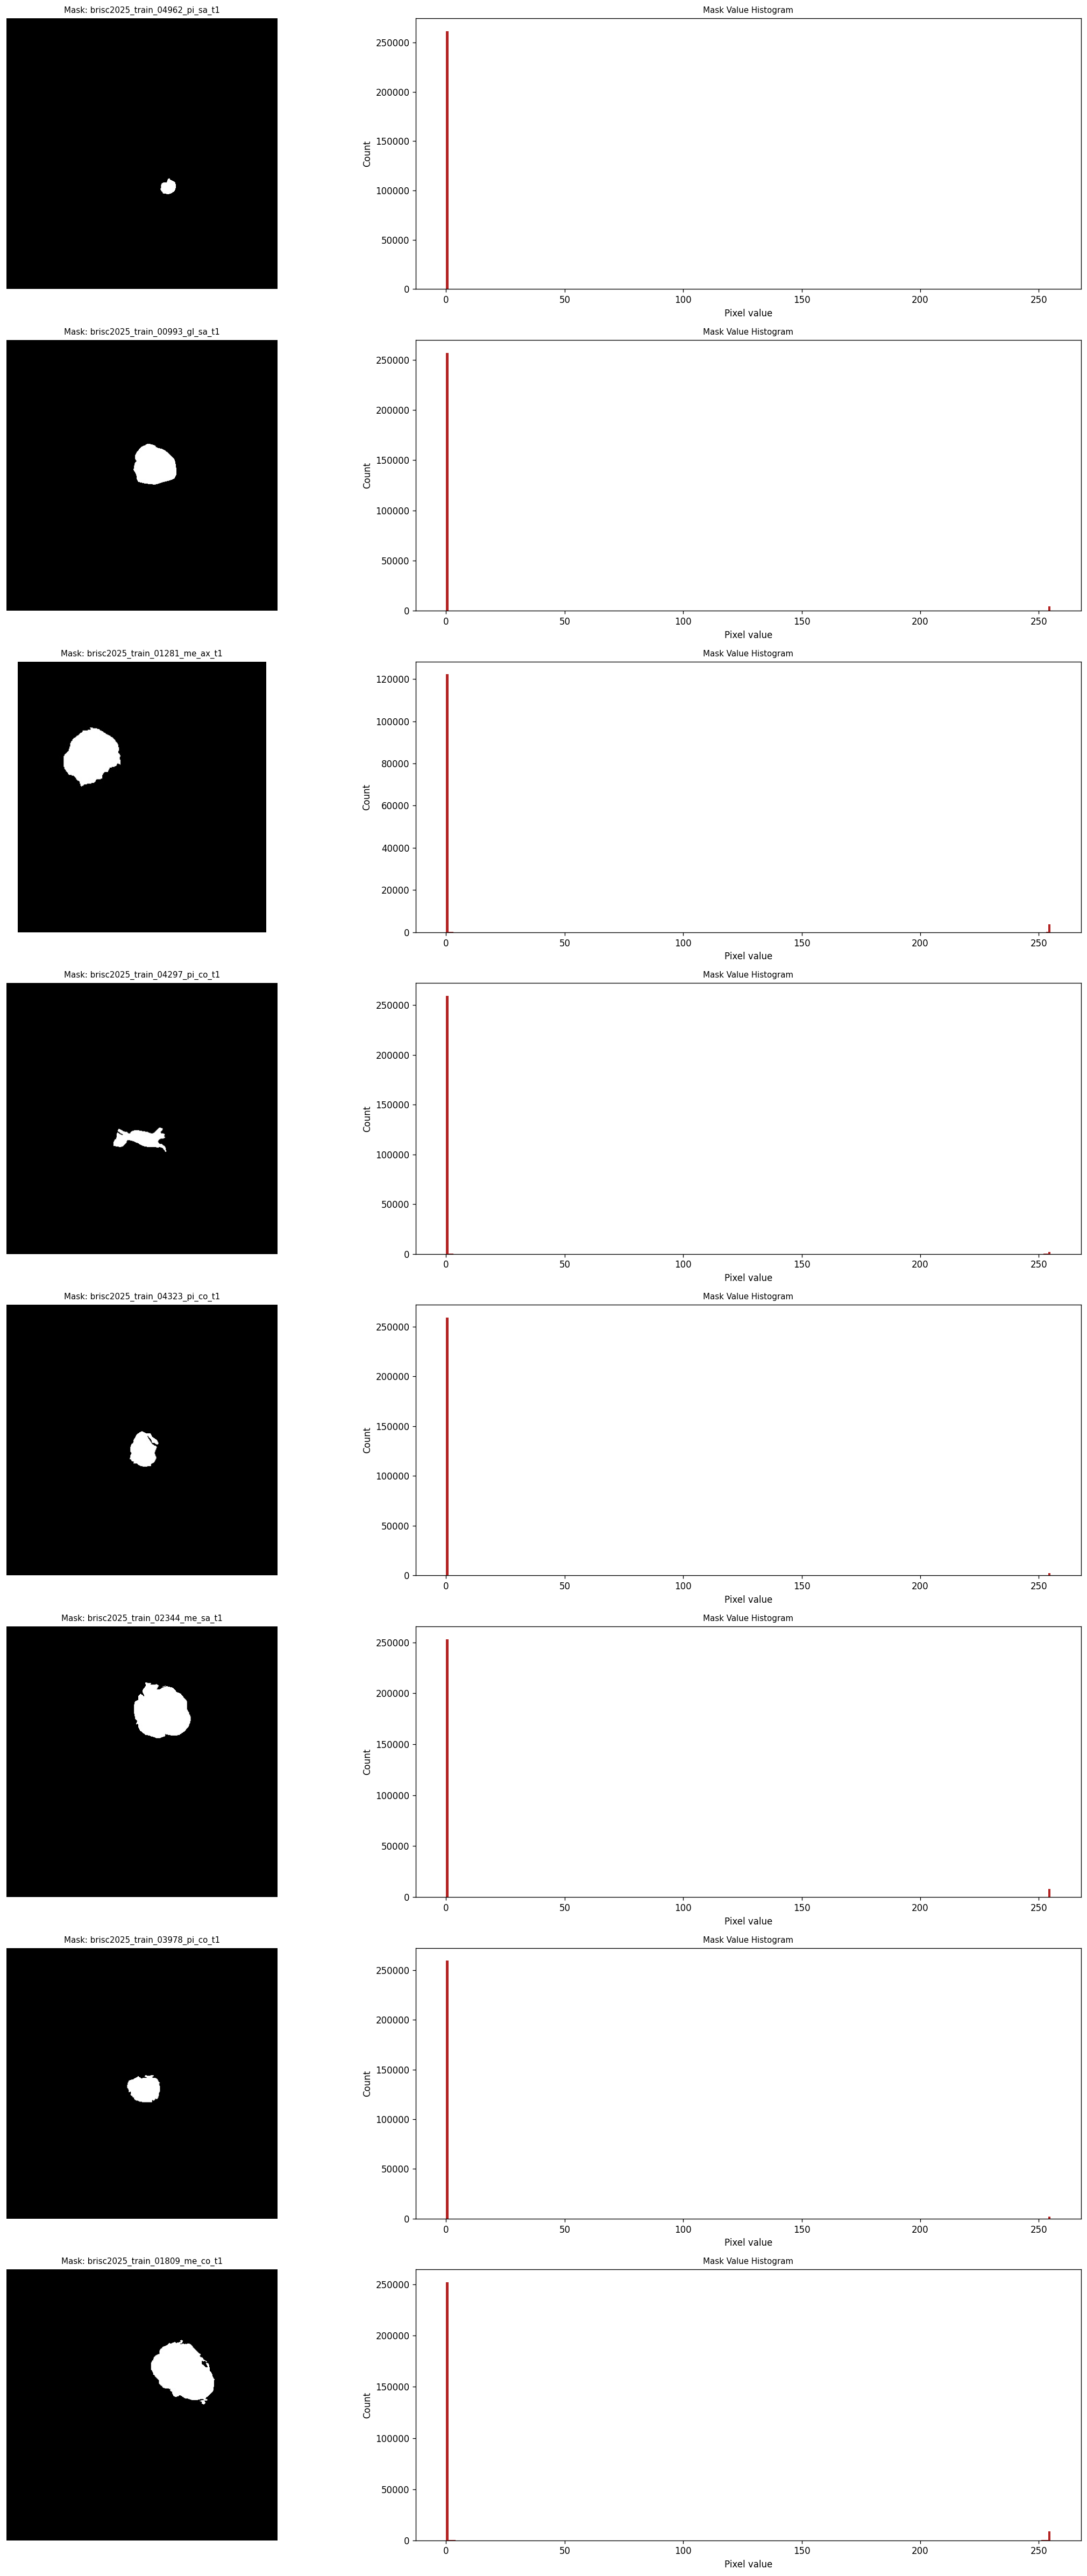

In [ ]:
show_masks_with_histogram(masks_path=train_mask_paths)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

In [ ]:
class BrainMRISegDataset(Dataset):
    """
    Dataset for MRI images and their segmentation masks.
    Image and mask are processed together with identical joint transforms
    to guarantee spatial alignment.

    Args:
        images_path (Path): path to the images folder (.jpg)
        masks_path (Path): path to the masks folder (.png)
        image_size (tuple): target size (H, W) — 512x512 recommended
        augment (bool): enable/disable augmentation (train split only)
        mask_threshold (int): pixel value above which a mask pixel is
        considered foreground (tumor). Raw masks contain noisy
        intermediate values (0-10, 246-255) instead of clean 0/255,
        so thresholding is required before using them as class indices.
    """
    def __init__(
        self, images_path, masks_path,
        image_size=(512, 512), augment=False,
        mask_threshold=127):

        self.images_path = Path(images_path)
        self.masks_path = Path(masks_path)
        self.image_size = image_size
        self.augment = augment
        self.mask_threshold = mask_threshold

        self.image_paths = sorted([
            p for p in self.images_path.iterdir()
            if p.is_file() and p.suffix.lower() == ".jpg"
        ])

        # Keep only images that have a matching mask
        self.pairs = []
        for image_path in self.image_paths:
            mask_path = self.masks_path / f"{image_path.stem}.png"
            if mask_path.exists():
                self.pairs.append((image_path, mask_path))
            else:
                print(f"Skipped (no mask): {image_path.name}")

    def __len__(self):
        return len(self.pairs)

    def _joint_transform(self, image, mask):
        """
        Applies identical spatial transforms to image and mask.
        Image: bilinear resize | Mask: nearest resize (preserves label boundaries)
        """
        # --- Mode normalization ---
        image = image.convert("L")   # always single-channel
        mask = mask.convert("L")

        # --- Resize to fixed target size ---
        image = TF.resize(image, self.image_size, interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.image_size, interpolation=TF.InterpolationMode.NEAREST)

        # --- Augmentation (train only) ---
        if self.augment:
            if rn.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if rn.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
            if rn.random() > 0.5:
                angle = rn.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

        # --- Convert to tensors ---
        image = TF.to_tensor(image)  # [1, H, W], values in [0, 1]

        # --- Threshold mask BEFORE converting to class indices ---
        # Raw mask pixels are not clean {0, 255}; they include noise from
        # compression/edge anti-aliasing (0-10, 246-255). Binarize first.
        mask_arr = np.array(mask)
        mask_arr = (mask_arr > self.mask_threshold).astype(np.int64)  # 0=background, 1=tumor
        mask = torch.as_tensor(mask_arr, dtype=torch.long)  # [H, W]

        # --- Normalize image only ---
        image = TF.normalize(image, mean=[0.5], std=[0.5])

        return image, mask

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]

        with Image.open(image_path) as img:
            image = img.copy()
        with Image.open(mask_path) as msk:
            mask = msk.copy()

        image, mask = self._joint_transform(image, mask)
        return image, mask

In [ ]:
import torch
from torch.utils.data import DataLoader

In [ ]:
train_dataset = BrainMRISegDataset(
    images_path=train_images_path,
    masks_path=train_mask_paths,
    image_size=(256, 256),
    augment=True
)

print(f"Number of samples: {len(train_dataset)}")

image, mask = train_dataset[0]

print(f"Image shape : {image.shape}, dtype: {image.dtype}")
print(f"Mask  shape : {mask.shape}, dtype: {mask.dtype}")
print(f"Image min/max: {image.min().item():.3f} / {image.max().item():.3f}")
print(f"Mask unique values: {torch.unique(mask)}")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)

images, masks = next(iter(train_loader))
print(f"\nBatch images shape: {images.shape}")   # [8, 1, 256, 256]
print(f"Batch masks shape : {masks.shape}")      # [8, 256, 256]
print(f"Batch mask unique values: {torch.unique(masks)}")

Number of samples: 3933
Image shape : torch.Size([1, 256, 256]), dtype: torch.float32
Mask  shape : torch.Size([256, 256]), dtype: torch.int64
Image min/max: -1.000 / 0.843
Mask unique values: tensor([0, 1])

Batch images shape: torch.Size([8, 1, 256, 256])
Batch masks shape : torch.Size([8, 256, 256])
Batch mask unique values: tensor([0, 1])


Saved to: test_dataloader.jpg


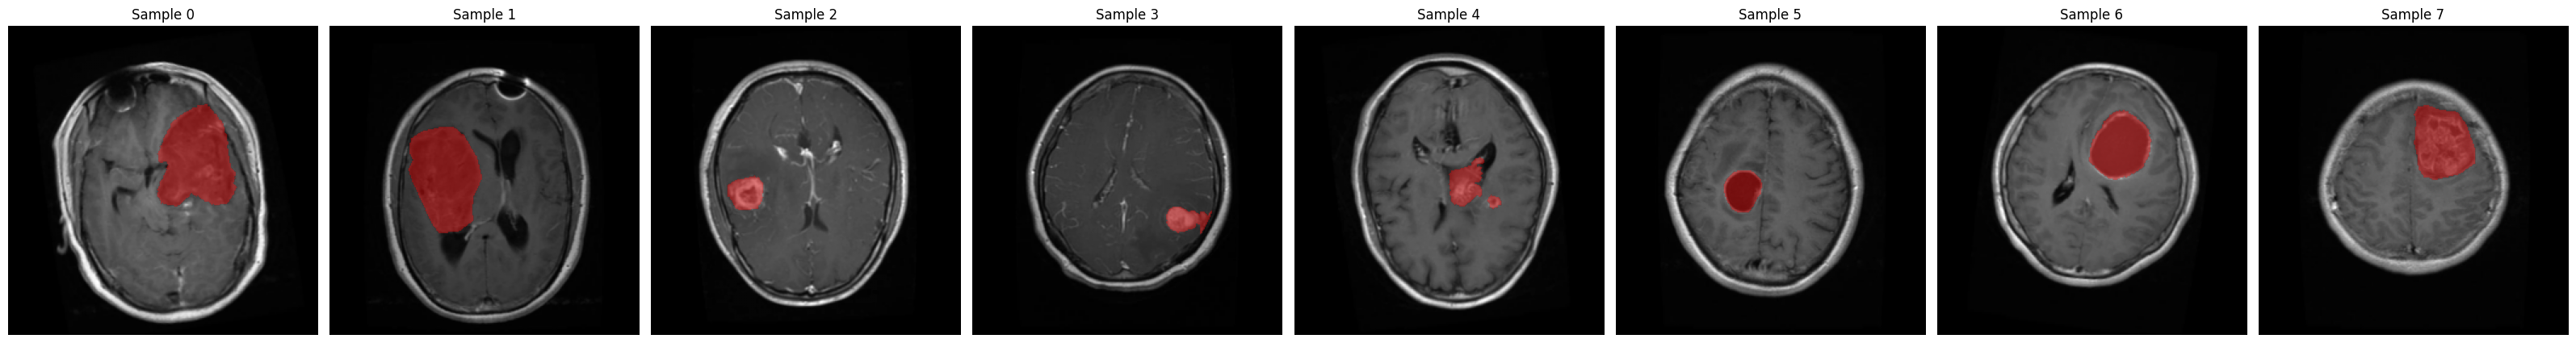

In [ ]:
def show_batch_with_overlay(dataset, n=4, save_path="test_dataloader.jpg", save=False):
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img, msk = dataset[i]

        img_np = img.squeeze().numpy()
        img_np = (img_np * 0.5) + 0.5

        mask_np = msk.numpy()

        axes[i].imshow(img_np, cmap="gray")
        axes[i].imshow(np.ma.masked_where(mask_np == 0, mask_np),
                        cmap="autumn", alpha=0.4)
        axes[i].set_title(f"Sample {i}")
        axes[i].axis("off")
    if save:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )
        print(f"Saved to: {save_path}")
    plt.tight_layout()
    plt.show()

show_batch_with_overlay(train_dataset, n=8, save=True)

In [ ]:
# =====================================
# TRAIN / VALIDATION STRATIFIED SPLIT
# =====================================

from pathlib import Path
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from collections import Counter


# ------------------------------------------------------------
# 1. Get all training image paths
# ------------------------------------------------------------

train_image_files = sorted(
    [
        p for p in train_images_path.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
)

print("Total training images:", len(train_image_files))


# ------------------------------------------------------------
# 2. Extract tumor type from filenames
# ------------------------------------------------------------

def get_tumor_type(image_path):
    """
    Extract tumor type from BRISC filename.

    gl = glioma
    me = meningioma
    pi = pituitary
    """

    filename = image_path.stem.lower()

    if "_gl_" in filename:
        return "gl"
    elif "_me_" in filename:
        return "me"
    elif "_pi_" in filename:
        return "pi"
    else:
        return "unknown"


stratify_labels = [
    get_tumor_type(image_path)
    for image_path in train_image_files
]


# ------------------------------------------------------------
# 3. Check for unknown labels
# ------------------------------------------------------------

unknown_count = stratify_labels.count("unknown")

if unknown_count > 0:
    print(f"WARNING: {unknown_count} images have unknown tumor type.")

print("\nTumor-type distribution:")

for label, count in sorted(Counter(stratify_labels).items()):
    percentage = 100 * count / len(stratify_labels)
    print(f"{label}: {count} ({percentage:.2f}%)")


# ------------------------------------------------------------
# 4. Create stratified Train / Validation split
# ------------------------------------------------------------

indices = np.arange(len(train_image_files))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=stratify_labels
)


# ------------------------------------------------------------
# 5. Verify split sizes
# ------------------------------------------------------------

print("\nSplit results:")
print(f"Train samples:      {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Total:               {len(train_indices) + len(val_indices)}")


# ------------------------------------------------------------
# 6. Verify stratification
# ------------------------------------------------------------

train_labels = [stratify_labels[i] for i in train_indices]
val_labels = [stratify_labels[i] for i in val_indices]

print("\nTRAIN distribution:")

for label, count in sorted(Counter(train_labels).items()):
    percentage = 100 * count / len(train_labels)
    print(f"{label}: {count} ({percentage:.2f}%)")


print("\nVALIDATION distribution:")

for label, count in sorted(Counter(val_labels).items()):
    percentage = 100 * count / len(val_labels)
    print(f"{label}: {count} ({percentage:.2f}%)")


# ------------------------------------------------------------
# 7. Create full datasets
# ------------------------------------------------------------

train_dataset_full = BrainMRISegDataset(
    images_path=train_images_path,
    masks_path=train_mask_paths,
    image_size=(256, 256),
    augment=True,
    mask_threshold=127
)

val_dataset_full = BrainMRISegDataset(
    images_path=train_images_path,
    masks_path=train_mask_paths,
    image_size=(256, 256),
    augment=False,
    mask_threshold=127
)


# ------------------------------------------------------------
# 8. Apply the same indices
# ------------------------------------------------------------

train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    val_dataset_full,
    val_indices
)


# ------------------------------------------------------------
# 9. Create DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# 10. Final verification
# ------------------------------------------------------------

train_images, train_masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))

print("\nTRAIN batch:")
print("Images:", train_images.shape, train_images.dtype)
print("Masks :", train_masks.shape, train_masks.dtype)
print("Mask values:", torch.unique(train_masks))

print("\nVALIDATION batch:")
print("Images:", val_images.shape, val_images.dtype)
print("Masks :", val_masks.shape, val_masks.dtype)
print("Mask values:", torch.unique(val_masks))

print("\n✓ Stratified Train/Validation split completed.")
print("✓ Training augmentation: ENABLED")
print("✓ Validation augmentation: DISABLED")
print("✓ BRISC Test split: UNTOUCHED")

Total training images: 3933

Tumor-type distribution:
gl: 1147 (29.16%)
me: 1329 (33.79%)
pi: 1457 (37.05%)

Split results:
Train samples:      3146
Validation samples: 787
Total:               3933

TRAIN distribution:
gl: 918 (29.18%)
me: 1063 (33.79%)
pi: 1165 (37.03%)

VALIDATION distribution:
gl: 229 (29.10%)
me: 266 (33.80%)
pi: 292 (37.10%)

TRAIN batch:
Images: torch.Size([8, 1, 256, 256]) torch.float32
Masks : torch.Size([8, 256, 256]) torch.int64
Mask values: tensor([0, 1])

VALIDATION batch:
Images: torch.Size([8, 1, 256, 256]) torch.float32
Masks : torch.Size([8, 256, 256]) torch.int64
Mask values: tensor([0, 1])

✓ Stratified Train/Validation split completed.
✓ Training augmentation: ENABLED
✓ Validation augmentation: DISABLED
✓ BRISC Test split: UNTOUCHED


In [ ]:
# ========================================
# U-NET WITH PRETRAINED RESNET34 ENCODER
# ========================================

import torch
import torch.nn as nn
from torchvision.models import resnet34, ResNet34_Weights


# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2. Pretrained ResNet34 Encoder
# ------------------------------------------------------------

class ResNet34Encoder(nn.Module):

    def __init__(self, in_channels=1):

        super().__init__()

        # Load ImageNet-pretrained ResNet34
        backbone = resnet34(
            weights=ResNet34_Weights.DEFAULT
        )

        # ----------------------------------------------------
        # Adapt first convolution from 3-channel RGB to
        # 1-channel grayscale MRI input.
        # ----------------------------------------------------

        original_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False
        )

        # Convert pretrained RGB weights to grayscale weights
        with torch.no_grad():

            new_conv.weight.copy_(
                original_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )
            )

        backbone.conv1 = new_conv

        # ----------------------------------------------------
        # ResNet34 feature stages
        # ----------------------------------------------------

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):

        # Initial feature extraction
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # 1/2 resolution
        x1 = x

        # 1/4 resolution
        x = self.maxpool(x)
        x = self.layer1(x)
        x2 = x

        # 1/8 resolution
        x = self.layer2(x)
        x3 = x

        # 1/16 resolution
        x = self.layer3(x)
        x4 = x

        # 1/32 resolution
        x = self.layer4(x)
        x5 = x

        return x1, x2, x3, x4, x5


# ------------------------------------------------------------
# 3. Decoder Block
# ------------------------------------------------------------

class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = nn.Sequential(

            nn.Conv2d(
                out_channels + skip_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.conv(x)

        return x


# ------------------------------------------------------------
# 4. U-Net with ResNet34 Encoder
# ------------------------------------------------------------

class ResNet34UNet(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=1
    ):

        super().__init__()

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.encoder = ResNet34Encoder(
            in_channels=in_channels
        )

        # ----------------------------------------------------
        # Decoder
        #
        # ResNet34 channels:
        #
        # x1 = 64
        # x2 = 64
        # x3 = 128
        # x4 = 256
        # x5 = 512
        # ----------------------------------------------------

        self.dec4 = DecoderBlock(
            in_channels=512,
            skip_channels=256,
            out_channels=256
        )

        self.dec3 = DecoderBlock(
            in_channels=256,
            skip_channels=128,
            out_channels=128
        )

        self.dec2 = DecoderBlock(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        self.dec1 = DecoderBlock(
            in_channels=64,
            skip_channels=64,
            out_channels=64
        )

        # ----------------------------------------------------
        # Final upsampling
        # ----------------------------------------------------

        self.final_up = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.final_conv = nn.Sequential(

            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                out_channels,
                kernel_size=1
            )
        )

    def forward(self, x):

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        x1, x2, x3, x4, x5 = self.encoder(x)

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        d4 = self.dec4(
            x5,
            x4
        )

        d3 = self.dec3(
            d4,
            x3
        )

        d2 = self.dec2(
            d3,
            x2
        )

        d1 = self.dec1(
            d2,
            x1
        )

        # ----------------------------------------------------
        # Final upsampling
        # ----------------------------------------------------

        out = self.final_up(d1)

        out = self.final_conv(out)

        return out


# ------------------------------------------------------------
# 5. Create model
# ------------------------------------------------------------

model = ResNet34UNet(
    in_channels=1,
    out_channels=1
).to(device)


# ------------------------------------------------------------
# 6. Model information
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nModel: U-Net + Pretrained ResNet34 Encoder")

print(
    f"Total parameters:     {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)


# ------------------------------------------------------------
# 7. Forward-pass test
# ------------------------------------------------------------

sample_images, sample_masks = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

with torch.no_grad():

    sample_output = model(
        sample_images
    )


print("\nForward-pass test:")

print(
    "Input shape :",
    sample_images.shape
)

print(
    "Output shape:",
    sample_output.shape
)


# ------------------------------------------------------------
# 8. Verify output shape
# ------------------------------------------------------------

assert sample_output.shape == (
    sample_images.shape[0],
    1,
    256,
    256
)

print(
    "\n✓ ResNet34-U-Net forward pass successful."
)

Device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 182MB/s]



Model: U-Net + Pretrained ResNet34 Encoder
Total parameters:     24,436,033
Trainable parameters: 24,436,033

Forward-pass test:
Input shape : torch.Size([8, 1, 256, 256])
Output shape: torch.Size([8, 1, 256, 256])

✓ ResNet34-U-Net forward pass successful.


In [ ]:
# ================
# LOSS FUNCTIONS
# ================

import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. Dice Loss
# ------------------------------------------------------------

class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.contiguous().view(
            probabilities.size(0),
            -1
        )

        targets = targets.float().contiguous().view(
            targets.size(0),
            -1
        )

        intersection = (
            probabilities * targets
        ).sum(dim=1)

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                probabilities.sum(dim=1)
                + targets.sum(dim=1)
                + self.smooth
            )
        )

        return 1.0 - dice.mean()


# ------------------------------------------------------------
# 2. BCE + Dice Loss
# ------------------------------------------------------------

class BCEDiceLoss(nn.Module):

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=0.5
    ):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        targets = targets.float()

        bce_loss = self.bce(
            logits,
            targets.unsqueeze(1)
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        total_loss = (
            self.bce_weight * bce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss


# ------------------------------------------------------------
# 3. Create criterion
# ------------------------------------------------------------

criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

print("Loss function: BCE + Dice")
print("BCE weight :", criterion.bce_weight)
print("Dice weight:", criterion.dice_weight)

Loss function: BCE + Dice
BCE weight : 0.5
Dice weight: 0.5


In [ ]:
# =====================================
# OPTIMIZER & TRAINING CONFIGURATION
# =====================================

import torch.optim as optim


# ------------------------------------------------------------
# 1. Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 40

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-5

BATCH_SIZE = 8

EARLY_STOPPING_PATIENCE = 7


# ------------------------------------------------------------
# 2. Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# 3. Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ------------------------------------------------------------
# 4. Configuration summary
# ------------------------------------------------------------

print("Training configuration:")
print(f"Epochs:              {NUM_EPOCHS}")
print(f"Batch size:          {BATCH_SIZE}")
print(f"Learning rate:       {LEARNING_RATE}")
print(f"Weight decay:        {WEIGHT_DECAY}")
print(f"Early stopping:      {EARLY_STOPPING_PATIENCE} epochs")
print("Optimizer:            AdamW")
print("Scheduler:             ReduceLROnPlateau")

Training configuration:
Epochs:              40
Batch size:          8
Learning rate:       0.0001
Weight decay:        1e-05
Early stopping:      7 epochs
Optimizer:            AdamW
Scheduler:             ReduceLROnPlateau


In [ ]:
# ======================
# SEGMENTATION METRICS
# ======================

import numpy as np


# ------------------------------------------------------------
# 1. Dice Score
# ------------------------------------------------------------

def dice_score(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = targets.float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.unsqueeze(1).view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    dice = (
        (2.0 * intersection + smooth)
        /
        (
            predictions.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return dice.mean().item()


# ------------------------------------------------------------
# 2. IoU
# ------------------------------------------------------------

def iou_score(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = targets.float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.unsqueeze(1).view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    union = (
        predictions
        +
        targets
        -
        predictions * targets
    ).sum(dim=1)

    iou = (
        (intersection + smooth)
        /
        (union + smooth)
    )

    return iou.mean().item()


# ------------------------------------------------------------
# 3. Precision
# ------------------------------------------------------------

def precision_score(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = targets.float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.unsqueeze(1).view(
        targets.size(0),
        -1
    )

    true_positive = (
        predictions * targets
    ).sum(dim=1)

    false_positive = (
        predictions * (1 - targets)
    ).sum(dim=1)

    precision = (
        (true_positive + smooth)
        /
        (
            true_positive
            +
            false_positive
            +
            smooth
        )
    )

    return precision.mean().item()


# ------------------------------------------------------------
# 4. Recall
# ------------------------------------------------------------

def recall_score(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = targets.float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.unsqueeze(1).view(
        targets.size(0),
        -1
    )

    true_positive = (
        predictions * targets
    ).sum(dim=1)

    false_negative = (
        (1 - predictions) * targets
    ).sum(dim=1)

    recall = (
        (true_positive + smooth)
        /
        (
            true_positive
            +
            false_negative
            +
            smooth
        )
    )

    return recall.mean().item()


# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

def accuracy_score(
    predictions,
    targets,
    threshold=0.5
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = targets.float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.unsqueeze(1).view(
        targets.size(0),
        -1
    )

    correct = (
        predictions == targets
    ).float()

    accuracy = correct.mean(
        dim=1
    )

    return accuracy.mean().item()


# ------------------------------------------------------------
# 6. Specificity
# ------------------------------------------------------------

def specificity_score(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = targets.float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.unsqueeze(1).view(
        targets.size(0),
        -1
    )

    true_negative = (
        (1 - predictions) * (1 - targets)
    ).sum(dim=1)

    false_positive = (
        predictions * (1 - targets)
    ).sum(dim=1)

    specificity = (
        (true_negative + smooth)
        /
        (
            true_negative
            +
            false_positive
            +
            smooth
        )
    )

    return specificity.mean().item()


# ------------------------------------------------------------
# Metrics loaded
# ------------------------------------------------------------

print("✓ Segmentation metrics loaded:")
print("  - Dice Score")
print("  - IoU")
print("  - Precision")
print("  - Recall")
print("  - Accuracy")
print("  - Specificity")

✓ Segmentation metrics loaded:
  - Dice Score
  - IoU
  - Precision
  - Recall
  - Accuracy
  - Specificity


In [ ]:
# ============================
# TRAINING & VALIDATION LOOP
# ============================

import time
import copy


# ------------------------------------------------------------
# 1. History
# ------------------------------------------------------------

history = {
    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_specificity": [],
    "val_specificity": [],

    "learning_rate": []
}


# ------------------------------------------------------------
# 2. Validation function
# ------------------------------------------------------------

def validate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    dice_values = []
    iou_values = []
    precision_values = []
    recall_values = []
    accuracy_values = []
    specificity_values = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Forward
            outputs = model(images)

            # Loss
            loss = criterion(
                outputs,
                masks
            )

            total_loss += (
                loss.item() * images.size(0)
            )

            # Metrics
            dice_values.append(
                dice_score(outputs, masks)
            )

            iou_values.append(
                iou_score(outputs, masks)
            )

            precision_values.append(
                precision_score(outputs, masks)
            )

            recall_values.append(
                recall_score(outputs, masks)
            )

            accuracy_values.append(
                accuracy_score(outputs, masks)
            )

            specificity_values.append(
                specificity_score(outputs, masks)
            )

    dataset_size = len(loader.dataset)

    return {
        "loss": total_loss / dataset_size,

        "dice": np.mean(dice_values),

        "iou": np.mean(iou_values),

        "precision": np.mean(precision_values),

        "recall": np.mean(recall_values),

        "accuracy": np.mean(accuracy_values),

        "specificity": np.mean(specificity_values)
    }


# ------------------------------------------------------------
# 3. Training
# ------------------------------------------------------------

best_val_dice = -np.inf

best_model_state = None

epochs_without_improvement = 0


print("Starting training...\n")


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # --------------------------------------------------------
    # Training mode
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0

    train_dice_values = []
    train_iou_values = []
    train_precision_values = []
    train_recall_values = []
    train_accuracy_values = []
    train_specificity_values = []


    # --------------------------------------------------------
    # Training batches
    # --------------------------------------------------------

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(
            outputs,
            masks
        )

        # Backward
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += (
            loss.item() * images.size(0)
        )

        # ----------------------------------------------------
        # Training metrics
        # ----------------------------------------------------

        train_dice_values.append(
            dice_score(outputs, masks)
        )

        train_iou_values.append(
            iou_score(outputs, masks)
        )

        train_precision_values.append(
            precision_score(outputs, masks)
        )

        train_recall_values.append(
            recall_score(outputs, masks)
        )

        train_accuracy_values.append(
            accuracy_score(outputs, masks)
        )

        train_specificity_values.append(
            specificity_score(outputs, masks)
        )


    # --------------------------------------------------------
    # Average training results
    # --------------------------------------------------------

    train_loss = (
        running_loss
        /
        len(train_loader.dataset)
    )

    train_dice = np.mean(
        train_dice_values
    )

    train_iou = np.mean(
        train_iou_values
    )

    train_precision = np.mean(
        train_precision_values
    )

    train_recall = np.mean(
        train_recall_values
    )

    train_accuracy = np.mean(
        train_accuracy_values
    )

    train_specificity = np.mean(
        train_specificity_values
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_results = validate_model(
        model,
        val_loader,
        criterion,
        device
    )

    val_loss = val_results["loss"]

    val_dice = val_results["dice"]

    val_iou = val_results["iou"]

    val_precision = val_results["precision"]

    val_recall = val_results["recall"]

    val_accuracy = val_results["accuracy"]

    val_specificity = val_results["specificity"]


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_dice
    )

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_dice"].append(
        train_dice
    )

    history["val_dice"].append(
        val_dice
    )

    history["train_iou"].append(
        train_iou
    )

    history["val_iou"].append(
        val_iou
    )

    history["train_precision"].append(
        train_precision
    )

    history["val_precision"].append(
        val_precision
    )

    history["train_recall"].append(
        train_recall
    )

    history["val_recall"].append(
        val_recall
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["train_specificity"].append(
        train_specificity
    )

    history["val_specificity"].append(
        val_specificity
    )

    history["learning_rate"].append(
        current_lr
    )


    # --------------------------------------------------------
    # Best model
    # --------------------------------------------------------

    if val_dice > best_val_dice:

        best_val_dice = val_dice

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_resnet34_unet.pth"
        )

        epochs_without_improvement = 0

        best_marker = " ★ BEST"

    else:

        epochs_without_improvement += 1

        best_marker = ""


    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Train Dice: {train_dice:.4f} "
        f"| Val Dice: {val_dice:.4f} "
        f"| Val IoU: {val_iou:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| Val Spec: {val_specificity:.4f} "
        f"| LR: {current_lr:.2e} "
        f"| Time: {elapsed:.1f}s"
        f"{best_marker}"
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered at epoch "
            f"{epoch + 1}."
        )

        break


# ------------------------------------------------------------
# 4. Restore best model
# ------------------------------------------------------------

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )


print("\n✓ Training completed.")

print(
    f"Best Validation Dice: "
    f"{best_val_dice:.4f}"
)

print(
    "Best model saved as: "
    "best_resnet34_unet.pth"
)

Starting training...

Epoch [01/40] | Train Loss: 0.6731 | Val Loss: 0.6212 | Train Dice: 0.5911 | Val Dice: 0.7601 | Val IoU: 0.6552 | Val Acc: 0.9934 | Val Spec: 0.9963 | LR: 1.00e-04 | Time: 60.7s ★ BEST
Epoch [02/40] | Train Loss: 0.5829 | Val Loss: 0.5454 | Train Dice: 0.7282 | Val Dice: 0.7672 | Val IoU: 0.6620 | Val Acc: 0.9933 | Val Spec: 0.9955 | LR: 1.00e-04 | Time: 61.9s ★ BEST
Epoch [03/40] | Train Loss: 0.5141 | Val Loss: 0.4907 | Train Dice: 0.7491 | Val Dice: 0.7317 | Val IoU: 0.6182 | Val Acc: 0.9905 | Val Spec: 0.9916 | LR: 1.00e-04 | Time: 64.4s
Epoch [04/40] | Train Loss: 0.4451 | Val Loss: 0.4060 | Train Dice: 0.7762 | Val Dice: 0.7957 | Val IoU: 0.7008 | Val Acc: 0.9941 | Val Spec: 0.9959 | LR: 1.00e-04 | Time: 65.1s ★ BEST
Epoch [05/40] | Train Loss: 0.3732 | Val Loss: 0.3531 | Train Dice: 0.7971 | Val Dice: 0.7969 | Val IoU: 0.7100 | Val Acc: 0.9941 | Val Spec: 0.9961 | LR: 1.00e-04 | Time: 63.7s ★ BEST
Epoch [06/40] | Train Loss: 0.3003 | Val Loss: 0.2712 | Trai

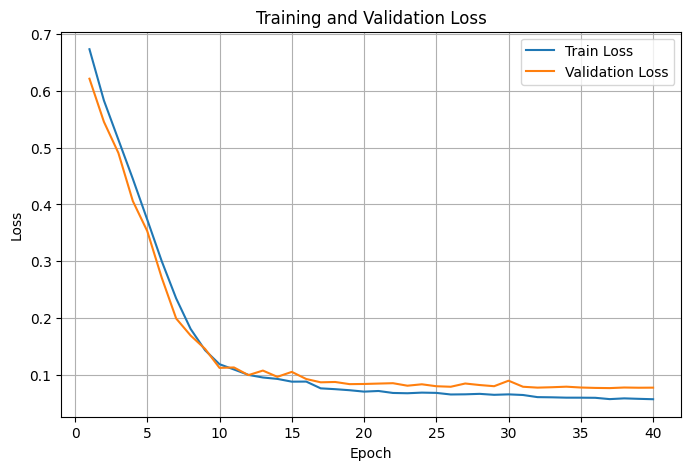

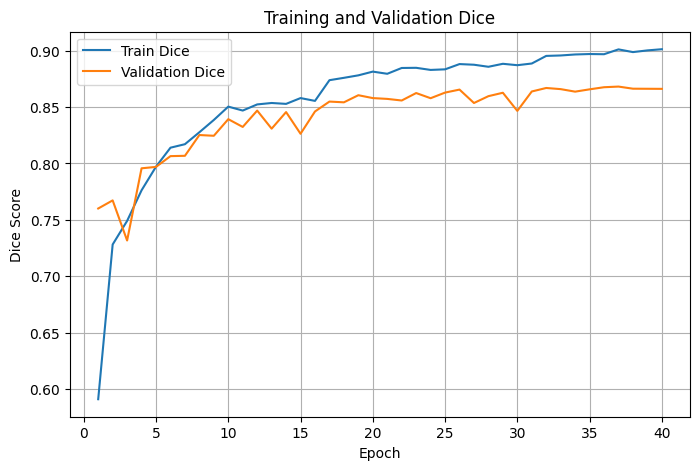

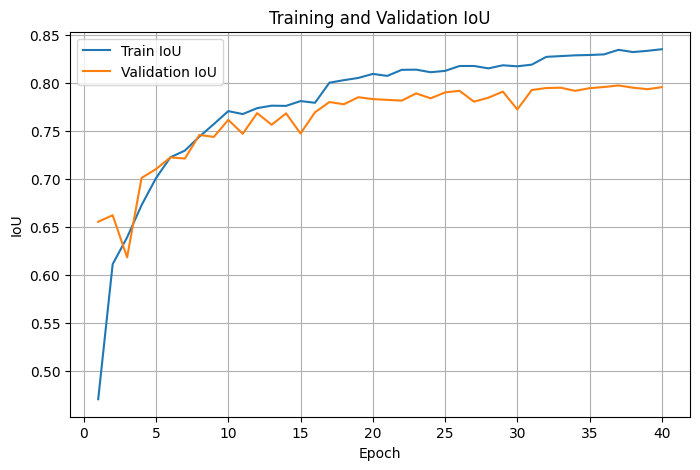

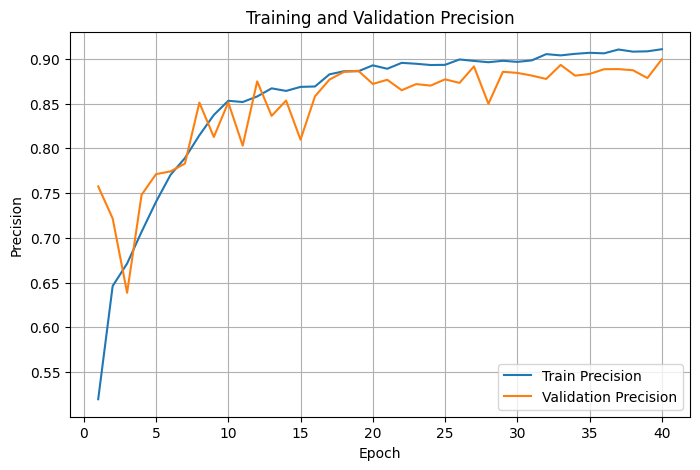

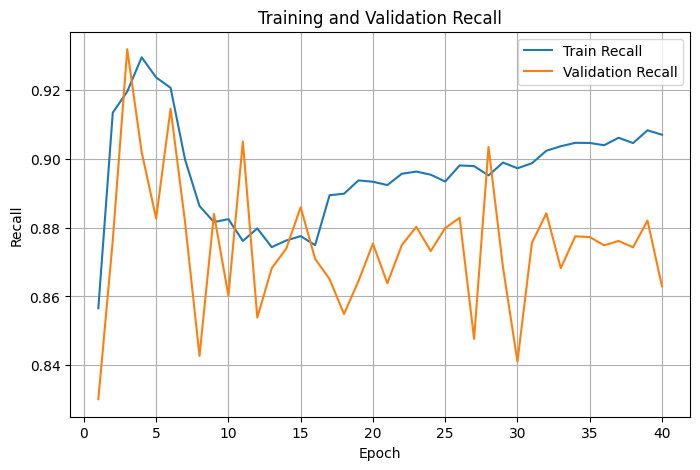

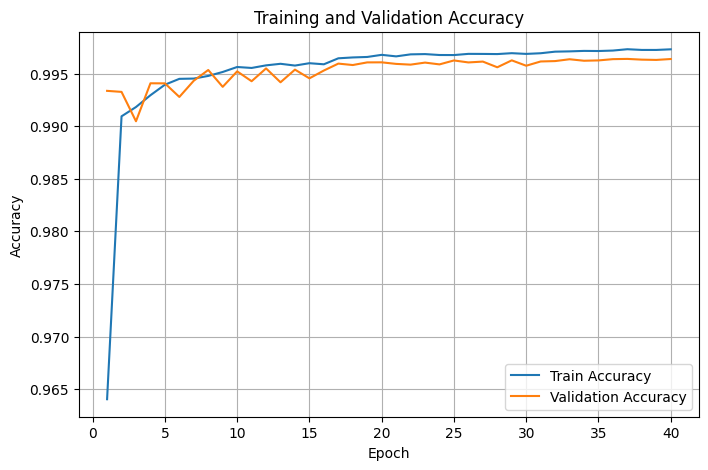

In [ ]:
# =================
# TRAINING CURVES
# =================

import matplotlib.pyplot as plt


epochs = range(
    1,
    len(history["train_loss"]) + 1
)


# ------------------------------------------------------------
# 1. Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()



# ------------------------------------------------------------
# 2. Dice Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_dice"],
    label="Train Dice"
)

plt.plot(
    epochs,
    history["val_dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice")

plt.legend()
plt.grid(True)
plt.show()



# ------------------------------------------------------------
# 3. IoU Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    epochs,
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU")

plt.legend()
plt.grid(True)
plt.show()



# ------------------------------------------------------------
# 4. Precision Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_precision"],
    label="Train Precision"
)

plt.plot(
    epochs,
    history["val_precision"],
    label="Validation Precision"
)

plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training and Validation Precision")

plt.legend()
plt.grid(True)
plt.show()



# ------------------------------------------------------------
# 5. Recall Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_recall"],
    label="Train Recall"
)

plt.plot(
    epochs,
    history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training and Validation Recall")

plt.legend()
plt.grid(True)
plt.show()



# ------------------------------------------------------------
# 6. Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =================================
# TEST DATASET & FINAL EVALUATION
# =================================


# ------------------------------------------------------------
# 1. Create Test Dataset
# ------------------------------------------------------------

test_dataset = BrainMRISegDataset(
    images_path=test_images_path,
    masks_path=test_mask_path,
    image_size=(256, 256),
    augment=False,
    mask_threshold=127
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


print("Test samples:", len(test_dataset))


# ------------------------------------------------------------
# 2. Load best ResNet34-U-Net model
# ------------------------------------------------------------

best_model_path = "best_resnet34_unet.pth"


model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)


model.to(device)


print("✓ Best ResNet34-U-Net model loaded.")


# ------------------------------------------------------------
# 3. Final Test Evaluation
# ------------------------------------------------------------

test_results = validate_model(
    model,
    test_loader,
    criterion,
    device
)


# ------------------------------------------------------------
# 4. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)


print(
    f"Dice Score : {test_results['dice']:.4f}"
)

print(
    f"IoU        : {test_results['iou']:.4f}"
)

print(
    f"Precision  : {test_results['precision']:.4f}"
)

print(
    f"Recall     : {test_results['recall']:.4f}"
)

print(
    f"Accuracy   : {test_results['accuracy']:.4f}"
)

print(
    f"Specificity: {test_results['specificity']:.4f}"
)

print(
    f"Loss       : {test_results['loss']:.4f}"
)


print("=" * 50)

Test samples: 860
✓ Best ResNet34-U-Net model loaded.

FINAL TEST RESULTS
Dice Score : 0.8731
IoU        : 0.8042
Precision  : 0.8793
Recall     : 0.8958
Accuracy   : 0.9964
Specificity: 0.9982
Loss       : 0.0741


In [ ]:
# =================
# HD95 EVALUATION
# =================

import numpy as np
import torch
from scipy.ndimage import distance_transform_edt
from scipy.spatial.distance import directed_hausdorff


# ------------------------------------------------------------
# Hausdorff Distance 95%
# ------------------------------------------------------------

def hd95_score(
    predictions,
    targets,
    threshold=0.5
):

    probabilities = torch.sigmoid(predictions)

    predictions = (
        probabilities >= threshold
    ).cpu().numpy()

    targets = (
        targets > 0
    ).cpu().numpy()


    hd95_values = []


    for pred, target in zip(
        predictions,
        targets
    ):

        # Remove channel dimension
        pred = pred.squeeze()
        target = target.squeeze()


        # If prediction or mask is empty
        if pred.sum() == 0 or target.sum() == 0:

            continue


        pred_points = np.argwhere(pred)
        target_points = np.argwhere(target)


        # Directed Hausdorff distances

        hd_forward = directed_hausdorff(
            pred_points,
            target_points
        )[0]


        hd_backward = directed_hausdorff(
            target_points,
            pred_points
        )[0]


        distances = np.concatenate(
            [
                np.array([hd_forward]),
                np.array([hd_backward])
            ]
        )


        hd95 = np.percentile(
            distances,
            95
        )


        hd95_values.append(
            hd95
        )


    if len(hd95_values) == 0:
        return np.nan


    return np.mean(hd95_values)



# ------------------------------------------------------------
# Calculate HD95 on Test Set
# ------------------------------------------------------------

model.eval()

hd95_values = []


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)


        outputs = model(images)


        batch_hd95 = hd95_score(
            outputs,
            masks
        )


        if not np.isnan(batch_hd95):

            hd95_values.append(
                batch_hd95
            )


final_hd95 = np.mean(
    hd95_values
)


print("=" * 50)
print("HD95 EVALUATION")
print("=" * 50)

print(
    f"HD95 : {final_hd95:.4f} pixels"
)

print("=" * 50)

HD95 EVALUATION
HD95 : 9.5113 pixels


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


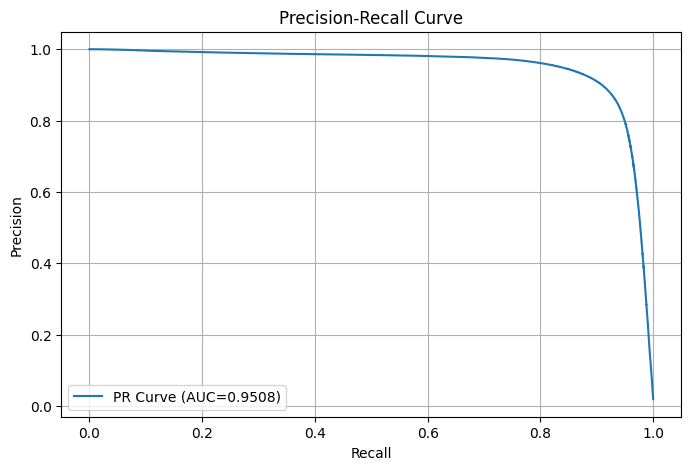

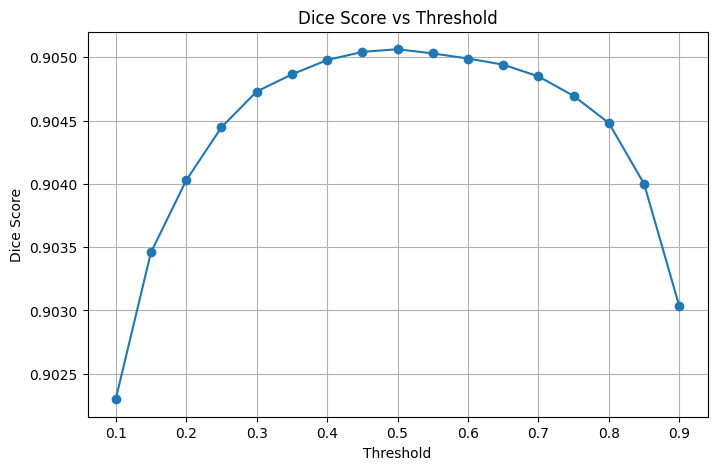

Best Threshold: 0.50
Best Dice: 0.9051


In [ ]:
# ============================================
# PRECISION-RECALL CURVE & DICE VS THRESHOLD
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    auc
)


# ------------------------------------------------------------
# Collect predictions from test set
# ------------------------------------------------------------

model.eval()

all_probabilities = []
all_targets = []


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(
            outputs
        )


        all_probabilities.append(
            probabilities.cpu().numpy()
        )

        all_targets.append(
            masks.cpu().numpy()
        )


all_probabilities = np.concatenate(
    all_probabilities
)

all_targets = np.concatenate(
    all_targets
)


# Flatten

y_scores = (
    all_probabilities
    .reshape(-1)
)

y_true = (
    all_targets
    .reshape(-1)
)


# ------------------------------------------------------------
# 1. Precision-Recall Curve
# ------------------------------------------------------------

precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)


pr_auc = auc(
    recall,
    precision
)


plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision,
    label=f"PR Curve (AUC={pr_auc:.4f})"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(True)

plt.show()



# ------------------------------------------------------------
# 2. Dice vs Threshold
# ------------------------------------------------------------

thresholds_list = np.arange(
    0.1,
    0.91,
    0.05
)


dice_values = []


for threshold in thresholds_list:


    predictions = (
        y_scores >= threshold
    ).astype(np.float32)


    intersection = (
        predictions * y_true
    ).sum()


    dice = (
        (2 * intersection + 1e-7)
        /
        (
            predictions.sum()
            +
            y_true.sum()
            +
            1e-7
        )
    )


    dice_values.append(
        dice
    )


best_threshold = thresholds_list[
    np.argmax(dice_values)
]


best_dice = max(
    dice_values
)


plt.figure(figsize=(8,5))


plt.plot(
    thresholds_list,
    dice_values,
    marker="o"
)


plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Dice Score"
)

plt.title(
    "Dice Score vs Threshold"
)


plt.grid(True)

plt.show()



print("=" * 50)

print(
    f"Best Threshold: {best_threshold:.2f}"
)

print(
    f"Best Dice: {best_dice:.4f}"
)

print("=" * 50)

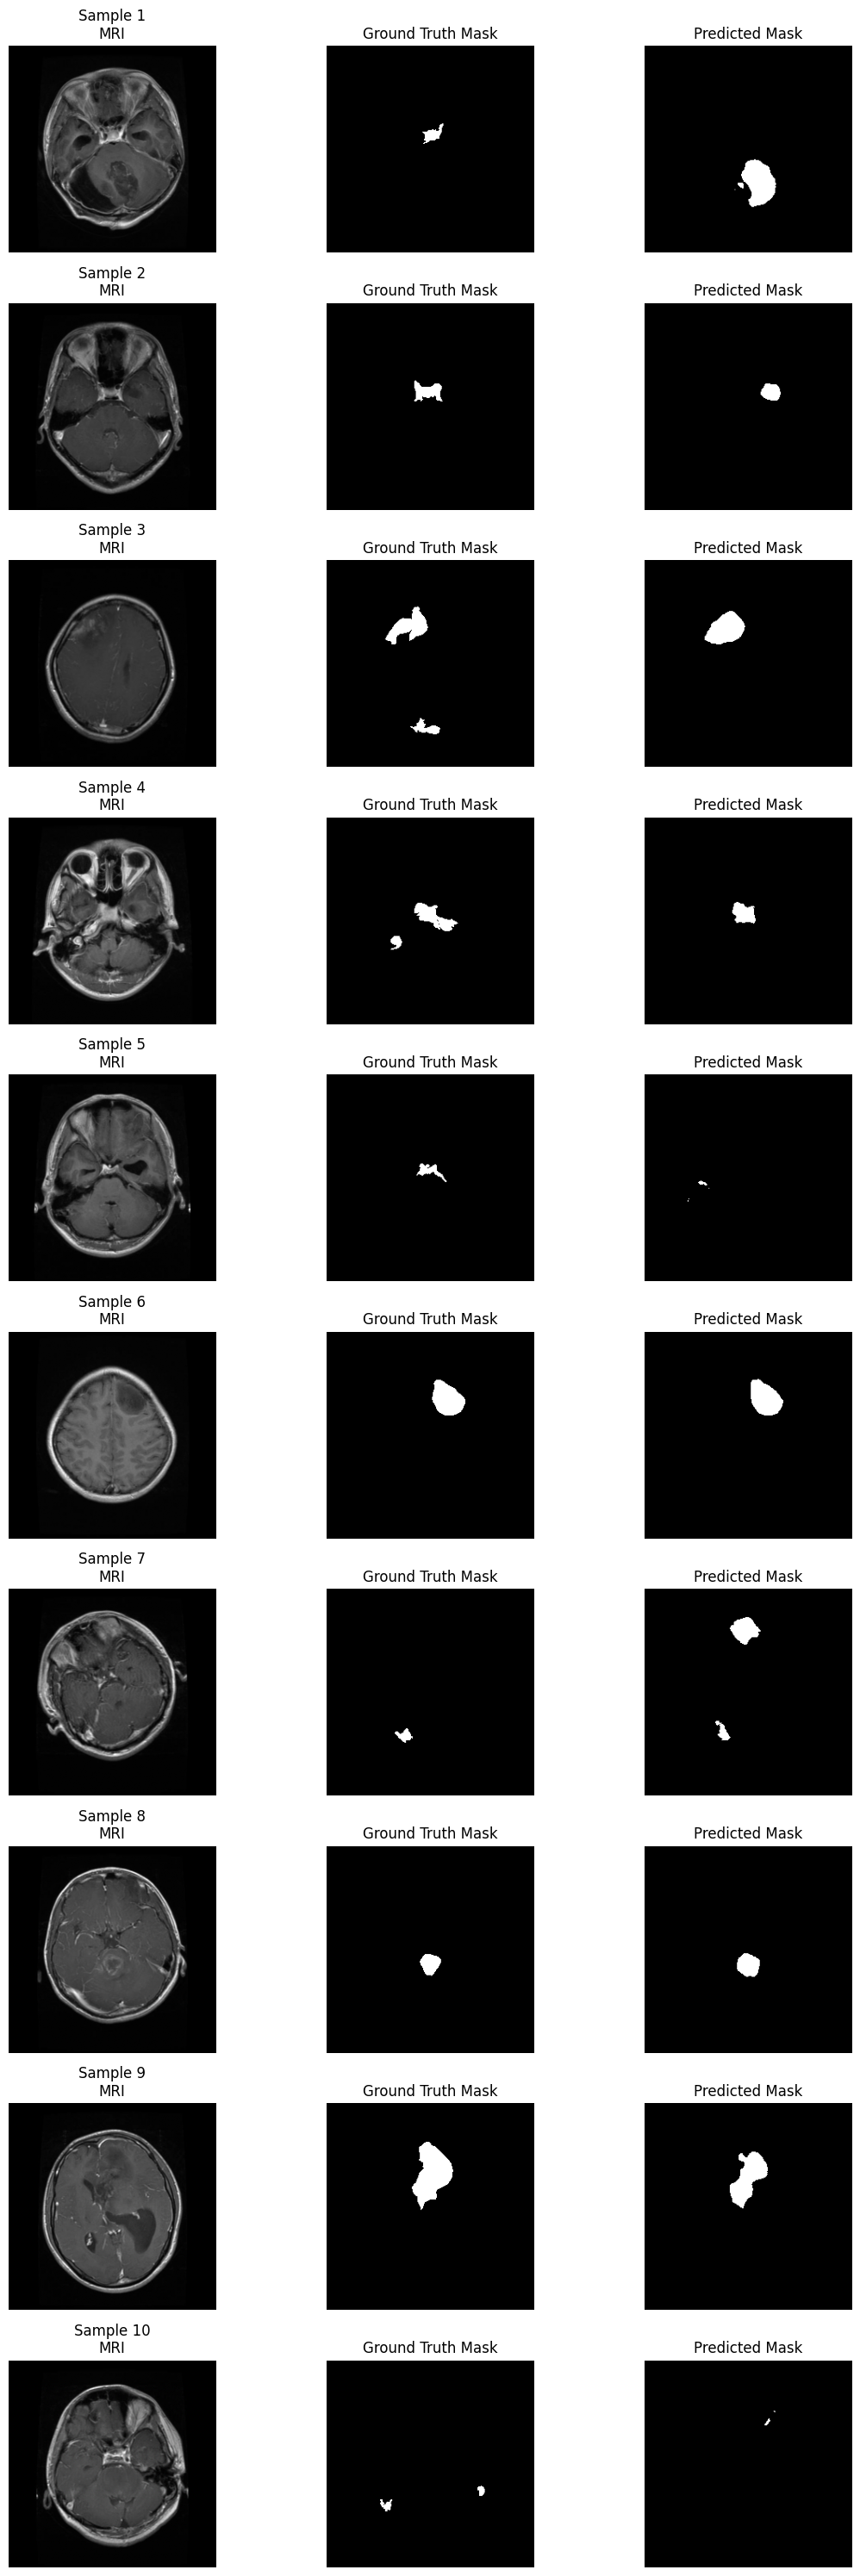

✓ Displayed 10 test predictions.


In [ ]:
# ============================
# VISUALIZE TEST PREDICTIONS
# ============================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Select samples
# ------------------------------------------------------------

num_samples = 10

model.eval()


samples_shown = 0


plt.figure(
    figsize=(12, num_samples * 3)
)


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)


        probabilities = torch.sigmoid(
            outputs
        )


        predictions = (
            probabilities >= 0.5
        ).float()


        images = images.cpu().numpy()

        masks = masks.cpu().numpy()

        predictions = predictions.cpu().numpy()


        batch_size = images.shape[0]


        for i in range(batch_size):

            if samples_shown >= num_samples:
                break


            # Remove channel dimension

            image = images[i].squeeze()

            true_mask = masks[i].squeeze()

            pred_mask = predictions[i].squeeze()



            # ------------------------------------------------
            # Original Image
            # ------------------------------------------------

            plt.subplot(
                num_samples,
                3,
                samples_shown * 3 + 1
            )

            plt.imshow(
                image,
                cmap="gray"
            )

            plt.title(
                f"Sample {samples_shown+1}\nMRI"
            )

            plt.axis("off")



            # ------------------------------------------------
            # Ground Truth Mask
            # ------------------------------------------------

            plt.subplot(
                num_samples,
                3,
                samples_shown * 3 + 2
            )

            plt.imshow(
                true_mask,
                cmap="gray"
            )

            plt.title(
                "Ground Truth Mask"
            )

            plt.axis("off")



            # ------------------------------------------------
            # Predicted Mask
            # ------------------------------------------------

            plt.subplot(
                num_samples,
                3,
                samples_shown * 3 + 3
            )

            plt.imshow(
                pred_mask,
                cmap="gray"
            )

            plt.title(
                "Predicted Mask"
            )

            plt.axis("off")


            samples_shown += 1


        if samples_shown >= num_samples:
            break



plt.tight_layout()

plt.show()


print(
    f"✓ Displayed {samples_shown} test predictions."
)